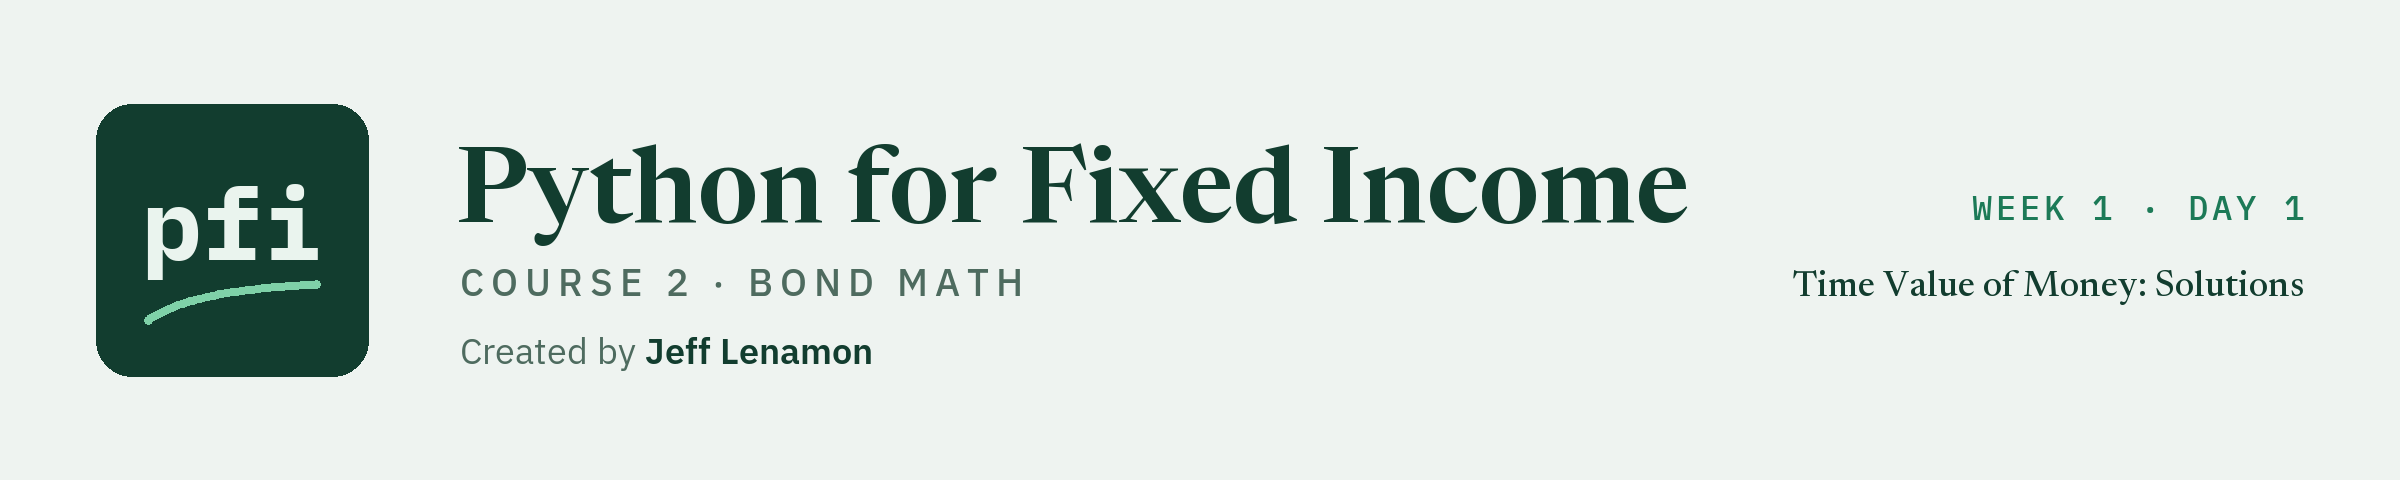

# Time Value of Money: Solutions

Week 1, Day 1. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week1/day1/01_time_value_of_money_solutions.ipynb)

This notebook stands on its own. Its setup writes `bondmath.py` and `test_bondmath.py` as they stand at the end of today, so the exercises can be run without the lesson.

Q. Set up today's work folder.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_01_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_01_i56wr5pc, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the end of today.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value']


## Exercises

The exercises use a second set of four new bonds, bought on 30 September 2026 like the first four. The issuers are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on with f-strings. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds and defines `check`, a small function that marks your answers.

In [5]:
exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30'],
    "years": [4, 2, 6, 8],
    "yield_pct": [5.8, 4.3, 5.35, 8.6],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,years,yield_pct
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,4,5.80
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,2,4.30
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,6,5.35
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,8,8.60


### Exercise 1

Q. With `bondmath.present_value`, find what each bond's 100 of redemption is worth today, at its own yield, compounded semiannually. Store Osmere's in **ex1_osmere**, unrounded, and the ticker of the bond whose redemption is worth least today in **ex1_lowest**.

In [6]:
# one present value for each bond, at its own yield and years
exercise_bonds["pv_of_redemption"] = [
    bondmath.present_value(100, y, t) for y, t in zip(exercise_bonds["yield_pct"], exercise_bonds["years"])
]
print(exercise_bonds[["ticker", "years", "yield_pct", "pv_of_redemption"]].round(4))

# Osmere is the third row; idxmin finds the row label of the smallest value
ex1_osmere = exercise_bonds.loc[exercise_bonds["ticker"] == "OSMC", "pv_of_redemption"].iloc[0]
ex1_lowest = exercise_bonds.loc[exercise_bonds["pv_of_redemption"].idxmin(), "ticker"]

print(f"Osmere: {ex1_osmere:.4f} per 100 of face. Lowest: {ex1_lowest}")

  ticker  years  yield_pct  pv_of_redemption
0   OSTV      4       5.80           79.5567
1   TRNW      2       4.30           91.8431
2   OSMC      6       5.35           72.8490
3   CLDB      8       8.60           50.9860
Osmere: 72.8490 per 100 of face. Lowest: CLDB


* Osmere's 100, due in 6 years at 5.35 percent, is worth 72.8490 today. Excel's `=-PV(5.35/100/2,2*6,0,100)` agrees to 13 decimal places.
* Calderby's is worth least, 50.9860: the highest yield and the longest wait of the four. Tarnwick's, 2 years at 4.30 percent, is worth most, 91.8431.

In [7]:
check("Exercise 1 Osmere", ex1_osmere, 72.84897770986194)
check("Exercise 1 lowest", ex1_lowest, "CLDB")

Exercise 1 Osmere: correct
Exercise 1 lowest: correct


### Exercise 2

Q. Build a ladder of discount factors: one row for every half-year from 0.5 to 5.0 years, one column for each bond's ticker, and in each cell the discount factor at that bond's yield, semiannual. Store the table in **ex2_ladder**, its number of rows in **ex2_rows**, and Calderby's discount factor at 5 years, unrounded, in **ex2_cldb_5y**.

In [8]:
# the half-years 0.5, 1.0, ..., 5.0
times = [k / 2 for k in range(1, 11)]

# one column for each bond: the present value of 1 at each time, at the bond's yield
ladder = {}
for ticker, yield_pct in zip(exercise_bonds["ticker"], exercise_bonds["yield_pct"]):
    ladder[ticker] = [bondmath.present_value(1, yield_pct, t) for t in times]

ex2_ladder = pd.DataFrame(ladder, index=times)
ex2_ladder.index.name = "years"
ex2_rows = len(ex2_ladder)
ex2_cldb_5y = ex2_ladder.loc[5.0, "CLDB"]

print(f"Rows: {ex2_rows}. Calderby at 5 years: {ex2_cldb_5y:.6f}")
ex2_ladder.round(6)

Rows: 10. Calderby at 5 years: 0.656382


,OSTV,TRNW,OSMC,CLDB
years,,,,
0.5,0.971817,0.978953,0.973947,0.958773
1.0,0.944429,0.958348,0.948573,0.919245
1.5,0.917812,0.938177,0.923859,0.881347
2.0,0.891946,0.918431,0.899790,0.845012
2.5,0.866808,0.899100,0.876348,0.810174
3.0,0.842379,0.880177,0.853516,0.776773
3.5,0.818639,0.861651,0.831279,0.744749
4.0,0.795567,0.843515,0.809622,0.714045
4.5,0.773146,0.825762,0.788529,0.684607


* 10 rows. Every column falls as the time grows, and the higher the yield, the faster it falls: at 5 years Calderby's factor is 0.656382 and Tarnwick's 0.808381.
* The ladder runs past Tarnwick's maturity on purpose. A discount factor belongs to a rate and a time, not to a bond. Day 2 uses one for every coupon date of a bond.

In [9]:
check("Exercise 2 rows", ex2_rows, 10)
check("Exercise 2 Calderby at 5 years", ex2_cldb_5y, 0.6563823821846481)

Exercise 2 rows: correct
Exercise 2 Calderby at 5 years: correct


### Exercise 3

Q. The desk has 1,000,000 dollars to place for Tarnwick's 2 years at 4.30 percent a year. How many more dollars does it end with if the rate compounds quarterly rather than annually? Store the difference in dollars, unrounded, in **ex3_difference**.

In [10]:
# the same amount, rate, and time; only the frequency changes
annual = bondmath.future_value(1_000_000, 4.30, 2, frequency=1)
quarterly = bondmath.future_value(1_000_000, 4.30, 2, frequency=4)
ex3_difference = quarterly - annual

print(f"Annual: {annual:,.2f} dollars. Quarterly: {quarterly:,.2f} dollars.")
print(f"Difference: {ex3_difference:,.2f} dollars")

Annual: 1,087,849.00 dollars. Quarterly: 1,089,306.26 dollars.
Difference: 1,457.26 dollars


* 1,457.26 dollars more with quarterly compounding, on the same quoted rate of 4.30 percent. A rate quoted without its frequency leaves that much undecided.

In [11]:
check("Exercise 3 difference", ex3_difference, 1457.2615362685174)

Exercise 3 difference: correct


### Exercise 4

Q. Add a function to your module. `discount_factor(rate_pct, years, frequency=2)` returns the value today of 1 due in `years`. Write the docstring first: units, convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_discount_factor_matches_excel_pv`, that checks it against every PV row of the reference file. Run pytest, and store `bondmath.discount_factor(5.35, 6)` in **ex4_value**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [12]:
%%writefile -a bondmath.py


def discount_factor(rate_pct: float, years: float, frequency: int = 2) -> float:
    """The value today of 1 due in `years`, at an annual rate compounded `frequency` times a year.

    Units: rate_pct in percent, years in years. Between 0 and 1 for a positive rate.
    Convention: periodic compounding, 1 / (1 + rate / frequency) ** (frequency x years).
    Excel: =-PV(rate_pct/100/frequency, frequency*years, 0, 1)
    """
    # the present value of 1 is the discount factor
    return present_value(1.0, rate_pct, years, frequency)

Appending to bondmath.py


In [13]:
%%writefile -a test_bondmath.py


def test_discount_factor_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        factor = bondmath.discount_factor(rate_pct, years, frequency)
        # Excel's PV of an amount is minus the amount times the discount factor
        assert factor * amount == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]

Appending to test_bondmath.py


In [14]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

....                                                                     [100%]
4 passed in 0.01s



In [15]:
# the file changed, so reload before calling the new function
importlib.reload(bondmath)

ex4_value = bondmath.discount_factor(5.35, 6)
print(f"Discount factor at 5.35 percent for 6 years, semiannual: {ex4_value:.6f}")

Discount factor at 5.35 percent for 6 years, semiannual: 0.728490


* `4 passed`: the three tests of the lesson and the new one, which checks the function against all 18 PV rows.
* 0.728490, which is Osmere's present value from Exercise 1 divided by 100. A discount factor is the present value of 1.
* The function calls `present_value` instead of repeating its formula, so a fix to one is a fix to both. Its Excel twin is `=-PV(5.35/100/2,2*6,0,1)`.
* The test compares `factor * amount` with minus Excel's PV, because each PV row discounts an amount, and Excel's PV is negative.
* Each `%%writefile -a` cell is run once. A second run would add a second copy to the file.

In [16]:
check("Exercise 4 discount factor", ex4_value, 0.7284897770986194)

Exercise 4 discount factor: correct


### Exercise 5: AI check

You ask an AI assistant to write `present_value` for you, and you give it the docstring as the request. In this course **the docstring is the prompt.** This is what you gave it:

```
Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
Returns a positive number for a positive amount. Excel's PV returns the same number with a
minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, it returns a reasonable number, and it contains one bug: a convention error.

* The bug: the code divided the percent rate by 100 but not by the frequency, and raised to the power `years` rather than `frequency * years`. It compounded once a year whatever the docstring and the `frequency` argument said. For Quorvane's 100 it returned 76.8771, the annual figure from section 1.4, instead of 76.6118.
* The test caught it on the first PV row, `tvm_pv_01`: 86.383760 against Excel's 86.229687. The rows with frequency 1 would have passed, which is why a test needs rows at more than one frequency.
* The fix, in the cell below: the rate per period is `rate_pct / 100 / frequency`, and there are `frequency * years` periods.

In [17]:
def assistant_present_value(amount, rate_pct, years, frequency=2):
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
Returns a positive number for a positive amount. Excel's PV returns the same number with a
minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the fix: a rate for one period, and one discount step for every period
    return amount / (1 + rate_pct / 100 / frequency) ** (frequency * years)

In [18]:
# the test, written from Excel's reference rows before the code is trusted
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
pv_rows = tvm[tvm["function"] == "PV"]

for row in pv_rows.itertuples():
    result = assistant_present_value(row.amount, row.rate_pct, row.years, row.frequency)
    # Excel's PV is negative, so the function should return minus the Excel value
    assert abs(result + row.excel_value) < 1e-6, f"{row.case_id}: {result:.6f} against Excel's {-row.excel_value:.6f}"

print(f"All {len(pv_rows)} PV rows match Excel")

All 18 PV rows match Excel


In [19]:
ex5_quorvane = assistant_present_value(100, 5.40, 5)
ex5_rows = len(pv_rows)

print(f"Quorvane's 100 from the fixed function: {ex5_quorvane:.4f}")
print(f"PV rows checked: {ex5_rows}")

Quorvane's 100 from the fixed function: 76.6118
PV rows checked: 18


* 76.6118, the semiannual figure, and all 18 PV rows match. The fixed function now does what its docstring says.

In [20]:
check("Exercise 5 Quorvane", ex5_quorvane, 76.61178196895271)
check("Exercise 5 rows checked", ex5_rows, 18)

Exercise 5 Quorvane: correct
Exercise 5 rows checked: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```